# How Does a Circle Equal a Triangle? 🔵 = 🔺

**Inspired by:** [Zack D. Films – *How Does A Circle Equal A Triangle*](https://www.youtube.com/shorts/yw391aK7EyQ)

We prove the area formula for a circle:

$$A_{\text{circle}} = \pi r^2$$

by showing that a circle can be **rearranged** into a **right triangle** whose area is exactly:

$$\frac{1}{2} \times \text{base} \times \text{height} = \frac{1}{2}(2\pi r)(r) = \pi r^2$$

No integration. No limits. Just geometry and the intuition of **"unrolling"** rings.

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

## Step 1 — Slice the Circle into Concentric Rings

Imagine slicing the circle into **many thin concentric rings**, like the layers of an onion.

Each ring sits at radius $r_i$ from the centre and has:
- **Thickness:** $dr$ (very thin)
- **Circumference:** $2\pi r_i$ (the length around the ring)
- **Area:** approximately $2\pi r_i \cdot dr$ (circumference × thickness)

The **total area** of the circle is the sum of all these rings:

$$A = \sum_{i} 2\pi r_i \, dr \quad \longrightarrow \quad \int_0^r 2\pi r \, dr = \pi r^2$$

But we don't need calculus to see this — we can **show it geometrically** in the next step.

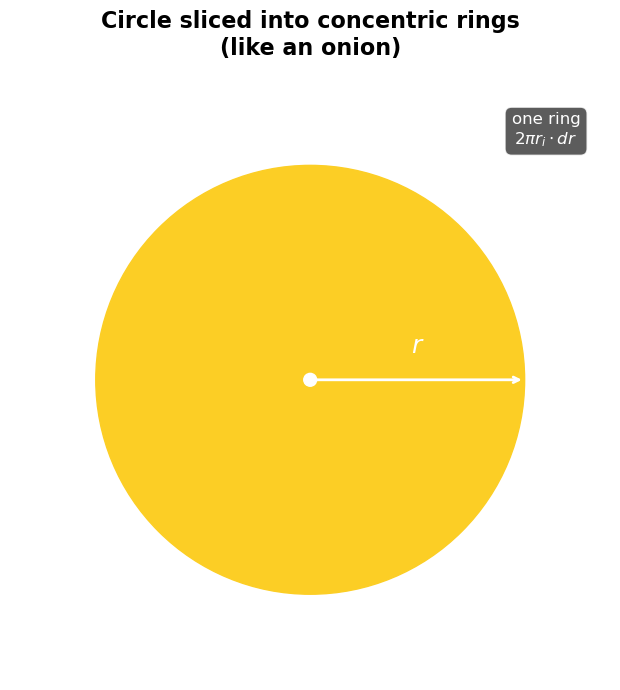

In [4]:
# === DIAGRAM 1: Circle sliced into concentric rings ===

r = 1.0
n_rings = 10
radii = np.linspace(0, r, n_rings + 1)

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Circle sliced into concentric rings\n(like an onion)',
             fontsize=16, fontweight='bold', pad=18)

cmap = plt.cm.plasma
colors = [cmap(i / n_rings) for i in range(n_rings)]

for i in range(n_rings - 1, -1, -1):
    ring = plt.Circle((0, 0), radii[i + 1], color=colors[i], zorder=i)
    ax.add_patch(ring)

# White dot at centre
ax.add_patch(plt.Circle((0, 0), 0.03, color='white', zorder=n_rings + 1))

# Radius label
ax.annotate('', xy=(r, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='white', lw=2),
            zorder=n_rings + 2)
ax.text(r / 2, 0.1, '$r$', fontsize=18, ha='center', va='bottom',
        color='white', fontweight='bold', zorder=n_rings + 3)

# Annotate one ring
mid_r = (radii[6] + radii[7]) / 2
ax.annotate('one ring\n$2\\pi r_i \\cdot dr$',
            xy=(mid_r * np.cos(np.pi / 4), mid_r * np.sin(np.pi / 4)),
            xytext=(1.1, 1.1),
            fontsize=12, ha='center', color='white',
            arrowprops=dict(arrowstyle='->', color='white', lw=1.5),
            bbox=dict(fc='#333', ec='white', boxstyle='round,pad=0.4', alpha=0.8))

plt.tight_layout()
plt.show()

## Step 2 — Cut & Unroll Each Ring Into a Strip

Now take **any one ring** and make a single cut through it.

When you **unroll** the ring, it flattens out into a (nearly) rectangular strip:

| Property | Value |
|---|---|
| Length of strip | $\approx 2\pi r_i$ (the circumference of that ring) |
| Height of strip | $dr$ (the ring's thickness) |
| Area of strip | $\approx 2\pi r_i \cdot dr$ |

The thinner the rings, the more perfectly rectangular the strips become.

> **Key insight:** The outermost ring has length $2\pi r$ (the full circumference of the circle).  
> The innermost ring shrinks all the way down to length $\approx 0$.

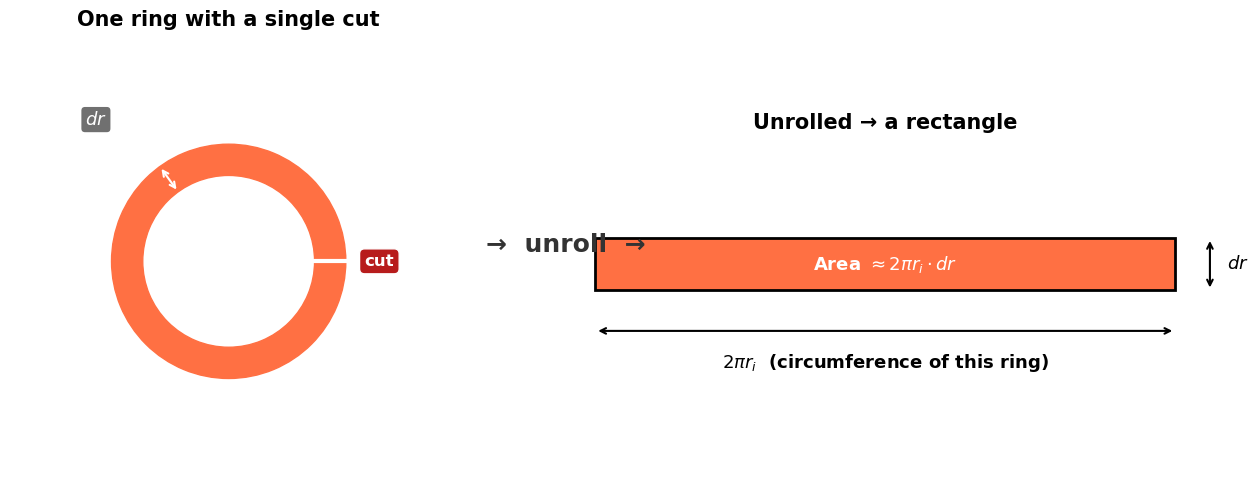

In [10]:
# === DIAGRAM 2: Cut one ring and unroll it into a rectangle ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: a single ring with a cut mark ──
ax = axes[0]
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('One ring with a single cut', fontsize=15, fontweight='bold', pad=12)

r_inner, r_outer = 0.55, 0.75
ring_patch = patches.Annulus((0, 0), r_outer, r_outer - r_inner, color='#FF7043', zorder=2)
ax.add_patch(ring_patch)

# Cut mark at angle 0 (right side)
ax.plot([r_inner, r_outer], [0, 0], color='white', lw=3, zorder=5)
ax.text(r_outer + 0.12, 0.0, 'cut', fontsize=12, va='center', color='white',
        fontweight='bold',
        bbox=dict(fc='#B71C1C', ec='white', boxstyle='round,pad=0.3'))

# Label ri
ax.annotate('', xy=(r_inner, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='white', lw=1.5))
ax.text(r_inner / 2, 0.1, '$r_i$', fontsize=14, ha='center', color='white', fontweight='bold')

# Label dr (thickness)
ax.annotate('', xy=(np.cos(np.pi*0.7)*r_outer, np.sin(np.pi*0.7)*r_outer),
            xytext=(np.cos(np.pi*0.7)*r_inner, np.sin(np.pi*0.7)*r_inner),
            arrowprops=dict(arrowstyle='<->', color='white', lw=1.5))
ax.text(-0.85, 0.85, '$dr$', fontsize=13, ha='center', va='bottom', color='white', fontweight='bold',
        bbox=dict(fc='#333', ec='none', boxstyle='round,pad=0.2', alpha=0.7))

# Central arrow label between panels
fig.text(0.5, 0.5, '→  unroll  →', fontsize=18, ha='center', va='center',
         fontweight='bold', color='#333')

# ── Right: the unrolled rectangle ──
ax2 = axes[1]
ax2.set_xlim(-0.5, 5.5)
ax2.set_ylim(-0.5, 1.5)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Unrolled → a rectangle', fontsize=15, fontweight='bold', pad=12)

strip_w = 5.0   # ≈ 2π r_i
strip_h = 0.45  # ≈ dr
rect = patches.Rectangle((0, 0.25), strip_w, strip_h,
                          facecolor='#FF7043', edgecolor='black', lw=2)
ax2.add_patch(rect)

# Width label
ax2.annotate('', xy=(strip_w, -0.1), xytext=(0, -0.1),
             arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax2.text(strip_w / 2, -0.28, r'$2\pi r_i$  (circumference of this ring)', fontsize=13,
         ha='center', va='top', fontweight='bold')

# Height label
ax2.annotate('', xy=(strip_w + 0.3, 0.25 + strip_h), xytext=(strip_w + 0.3, 0.25),
             arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax2.text(strip_w + 0.45, 0.25 + strip_h / 2, '$dr$', fontsize=13,
         ha='left', va='center', fontweight='bold')

# Area label inside the strip
ax2.text(strip_w / 2, 0.25 + strip_h / 2,
         r'Area $\approx 2\pi r_i \cdot dr$',
         fontsize=13, ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

## Step 3 — Stack All Unrolled Rings Into a Triangle

Now unroll **every** ring in the circle, from the largest (radius $r$, length $2\pi r$) down to the smallest (radius $\approx 0$, length $\approx 0$).

Stack the strips **on top of each other**, widest at the bottom, narrowest at the top.

The shape they form is a **right triangle** with:
- **Base** $= 2\pi r$ (circumference of the original circle)
- **Height** $= r$ (radius of the original circle)

Therefore:

$$A_{\text{triangle}} = \frac{1}{2} \times \text{base} \times \text{height} = \frac{1}{2} \times 2\pi r \times r = \pi r^2$$

$$\boxed{A_{\text{circle}} = \pi r^2}$$

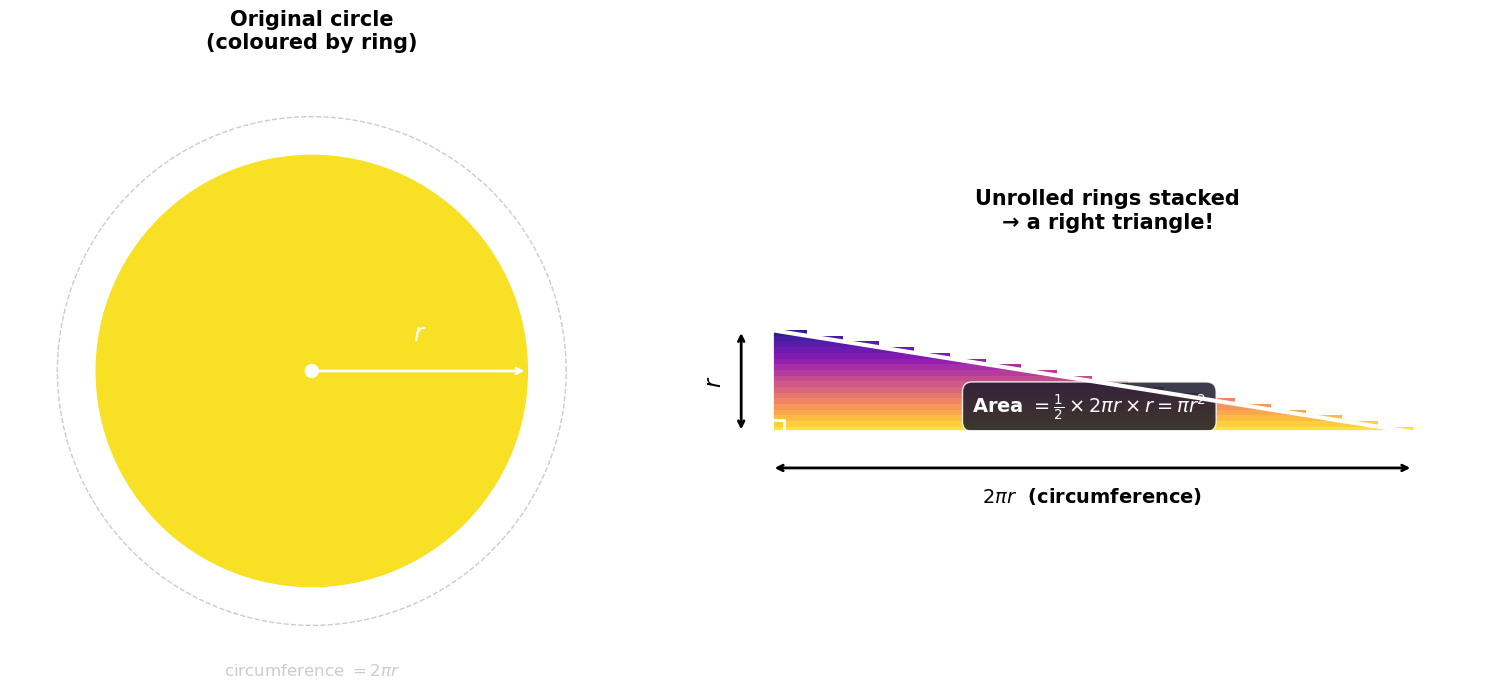

In [11]:
# === DIAGRAM 3: All rings unrolled and stacked → right triangle ===

r = 1.0
n_rings = 18
radii = np.linspace(0, r, n_rings + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cmap = plt.cm.plasma
colors = [cmap(i / n_rings) for i in range(n_rings)]

# ──── Left: original circle with coloured rings ────
ax1 = axes[0]
ax1.set_xlim(-1.4, 1.4)
ax1.set_ylim(-1.4, 1.4)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Original circle\n(coloured by ring)', fontsize=15, fontweight='bold', pad=15)

for i in range(n_rings - 1, -1, -1):
    c = plt.Circle((0, 0), radii[i + 1], color=colors[i], zorder=i)
    ax1.add_patch(c)

ax1.add_patch(plt.Circle((0, 0), 0.03, color='white', zorder=n_rings + 1))
ax1.annotate('', xy=(r, 0), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='white', lw=2), zorder=n_rings + 2)
ax1.text(r / 2, 0.12, '$r$', fontsize=18, ha='center', va='bottom',
         color='white', fontweight='bold', zorder=n_rings + 3)

theta_arc = np.linspace(0, 2 * np.pi, 300)
ax1.plot(1.18 * np.cos(theta_arc), 1.18 * np.sin(theta_arc), color='#ccc', lw=1, ls='--')
ax1.text(0, -1.35, r'circumference $= 2\pi r$', fontsize=12, ha='center', va='top', color='#ccc')

# ──── Right: stacked strips forming a triangle ────
ax2 = axes[1]
base = 2 * np.pi * r
height = r
strip_height = height / n_rings

ax2.set_xlim(-0.5, base + 0.8)
ax2.set_ylim(-0.6, height + 0.8)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Unrolled rings stacked\n→ a right triangle!', fontsize=15, fontweight='bold', pad=15)

for i in range(n_rings):
    strip_width = 2 * np.pi * radii[n_rings - i]   # widest at bottom
    y0 = i * strip_height
    rect = patches.Rectangle((0, y0), strip_width, strip_height,
                              facecolor=colors[n_rings - 1 - i],
                              edgecolor='none', alpha=0.9)
    ax2.add_patch(rect)

# Triangle outline
triangle = plt.Polygon([(0, 0), (base, 0), (0, height)],
                       fill=False, edgecolor='white', lw=3, zorder=10)
ax2.add_patch(triangle)

# Base label
ax2.annotate('', xy=(base, -0.35), xytext=(0, -0.35),
             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax2.text(base / 2, -0.52, r'$2\pi r$  (circumference)', fontsize=14,
         ha='center', va='top', fontweight='bold')

# Height label
ax2.annotate('', xy=(-0.3, height), xytext=(-0.3, 0),
             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax2.text(-0.45, height / 2, '$r$', fontsize=16, ha='right', va='center',
         fontweight='bold', rotation=90)

# Area annotation
ax2.text(base / 3.2, height / 4,
         r'Area $= \frac{1}{2} \times 2\pi r \times r = \pi r^2$',
         fontsize=14, ha='left', va='center', color='white', fontweight='bold',
         bbox=dict(fc='#1a1a2e', ec='white', boxstyle='round,pad=0.5', alpha=0.85))

# Right-angle mark
sq = patches.Rectangle((0, 0), 0.12, 0.12, fill=False, edgecolor='white', lw=2, zorder=11)
ax2.add_patch(sq)

plt.tight_layout()
plt.show()

## Step 4 — Why the Hypotenuse Is a Straight Line

A natural question: why does the right edge of the stacked strips form a **perfectly straight** diagonal (the hypotenuse), and not a curve?

Each strip at radius $r_i$ has:
- **Width** $= 2\pi r_i$
- **Vertical position** $= r_i$ (it is the $i$-th layer up from the bottom)

So the **right edge** of strip $i$ sits at the point $(2\pi r_i,\ r_i)$.

As $r_i$ increases from $0$ to $r$, this point traces:

$$x = 2\pi r_i, \quad y = r_i \quad \Longrightarrow \quad x = 2\pi \, y$$

That is a **linear** relationship — a straight line through the origin with slope $2\pi$.  
Hence the hypotenuse is indeed straight. ✅

The triangle has a right angle at the **bottom-left**, with:
- Horizontal leg $= 2\pi r$
- Vertical leg $= r$

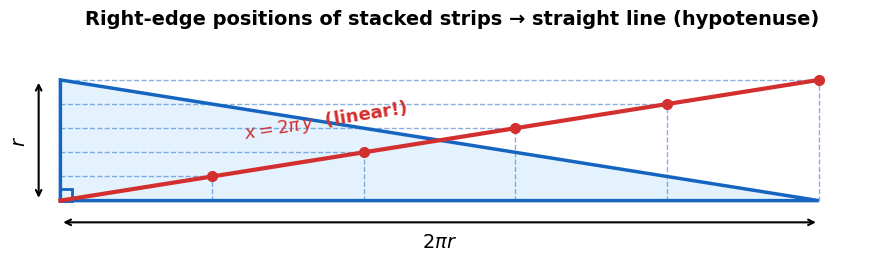

In [12]:
# === DIAGRAM 4: Why the hypotenuse is a straight line ===

r_vals = np.linspace(0, 1, 200)
x_edge = 2 * np.pi * r_vals
y_edge = r_vals

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xlim(-0.3, 2 * np.pi + 0.5)
ax.set_ylim(-0.3, 1.3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Right-edge positions of stacked strips → straight line (hypotenuse)',
             fontsize=14, fontweight='bold', pad=14)

# Shaded triangle
tri = plt.Polygon([(0, 0), (2 * np.pi, 0), (0, 1)],
                  facecolor='#E3F2FD', edgecolor='#1565C0', lw=2.5)
ax.add_patch(tri)

# The right-edge locus
ax.plot(x_edge, y_edge, color='#D32F2F', lw=3, zorder=5)

# Sample points along the hypotenuse
sample_r = [0.2, 0.4, 0.6, 0.8, 1.0]
for ri in sample_r:
    xi, yi = 2 * np.pi * ri, ri
    ax.plot(xi, yi, 'o', color='#D32F2F', ms=7, zorder=6)
    ax.plot([xi, xi], [0, yi], '--', color='#1565C0', lw=1, alpha=0.5)
    ax.plot([0, xi], [yi, yi], '--', color='#1565C0', lw=1, alpha=0.5)

# Axis labels
ax.annotate('', xy=(2 * np.pi, -0.18), xytext=(0, -0.18),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(np.pi, -0.26, r'$2\pi r$', fontsize=14, ha='center', va='top', fontweight='bold')

ax.annotate('', xy=(-0.18, 1), xytext=(-0.18, 0),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(-0.26, 0.5, '$r$', fontsize=14, ha='right', va='center', fontweight='bold', rotation=90)

# Equation on the hypotenuse
ax.text(2.2, 0.47, r'$x = 2\pi\, y$  (linear!)', fontsize=13,
        ha='center', va='bottom', color='#D32F2F', fontweight='bold',
        rotation=np.degrees(np.arctan2(1, 2 * np.pi)))

# Right-angle mark
sq = patches.Rectangle((0, 0), 0.1, 0.1, fill=False, edgecolor='#1565C0', lw=2)
ax.add_patch(sq)

plt.tight_layout()
plt.show()

## Summary — The Full Proof at a Glance

| Step | What We Did | Result |
|:---:|---|---|
| 1 | Sliced the circle into $n$ thin concentric rings | Each ring has area $\approx 2\pi r_i \cdot dr$ |
| 2 | Cut & unrolled each ring into a flat strip | Strip width $= 2\pi r_i$, height $= dr$ |
| 3 | Stacked all strips, widest at bottom | The shape is a **right triangle** |
| 4 | Checked the hypotenuse is straight | Right-edge satisfies $x = 2\pi y$ — linear ✅ |
| 5 | Computed the triangle's area | $\tfrac{1}{2} \times 2\pi r \times r = \pi r^2$ ✅ |

The area of the circle **equals** the area of that triangle:

$$\boxed{A_{\text{circle}} = \frac{1}{2} \times 2\pi r \times r = \pi r^2}$$

---

### Connection to the Polygon Formula

Notice that the final triangle has:
- **Base** $= 2\pi r$ → the *circumference* of the circle
- **Height** $= r$ → the *radius* of the circle

So another way to remember this:

$$A_{\text{circle}} = \frac{1}{2} \times C \times r \qquad \text{where } C = 2\pi r$$

This mirrors the formula for a regular polygon:
$$A_{\text{polygon}} = \frac{1}{2} \times \text{perimeter} \times \text{apothem}$$

hinting that a **circle is the limit of a regular polygon** with infinitely many sides.

> This argument is essentially what **Archimedes** used around 250 BC, and it is a geometric shadow of the integral $\int_0^r 2\pi r\,dr = \pi r^2$.

In [8]:
# === Numerical Verification ===

r = 5  # choose any radius

area_formula   = np.pi * r**2
triangle_area  = 0.5 * (2 * np.pi * r) * r

print(f"Radius r = {r}")
print()
print(f"Circle area   = π × r²       = {area_formula:.6f}")
print(f"Triangle area = ½ × 2πr × r  = {triangle_area:.6f}")
print()
print(f"Equal? {np.isclose(area_formula, triangle_area)} ✓")
print()
print("Numerical integration check (summing thin rings):")
n   = 1_000_000
dr  = r / n
ring_sum = sum(2 * np.pi * ri * dr for ri in np.linspace(0, r, n))
print(f"  Sum of {n:,} ring areas = {ring_sum:.6f}")
print(f"  Matches π r²?          {np.isclose(ring_sum, area_formula, rtol=1e-4)} ✓")

Radius r = 5

Circle area   = π × r²       = 78.539816
Triangle area = ½ × 2πr × r  = 78.539816

Equal? True ✓

Numerical integration check (summing thin rings):
  Sum of 1,000,000 ring areas = 78.539816
  Matches π r²?          True ✓
